# Assignment 1 - Text Classification (RNN vs Transformer)

## Mục tiêu của notebook
Notebook này triển khai **toàn bộ phần 4.2** của assignment: so sánh mô hình thuộc hai nhóm:

- **RNN**: BiLSTM với **pretrained GloVe embeddings**
- **Transformer**: **DistilBERT** fine-tuning cho phân loại đa lớp

## Vì sao chọn dataset này?
Chọn **20 Newsgroups** vì phù hợp tốt với ràng buộc của đề:
- **20 lớp** (đạt yêu cầu tối thiểu ≥ 5 lớp)
- **18,846 mẫu** tổng cộng, trong đó tập train đủ lớn để huấn luyện mô hình
- Văn bản có **độ dài và ngữ nghĩa đa dạng**, phù hợp hơn các dataset quá ngắn / quá dễ
- Bản trên Hugging Face đã **loại bỏ headers, signatures, quotations** theo thực hành khuyến nghị

## Cấu trúc notebook
1. Cài đặt và import thư viện
2. Tải và kiểm tra dataset
3. EDA cơ bản
4. Chuẩn bị dữ liệu cho RNN
5. Huấn luyện và đánh giá BiLSTM
6. Chuẩn bị dữ liệu cho Transformer
7. Huấn luyện và đánh giá DistilBERT
8. So sánh kết quả bằng bảng số liệu, biểu đồ và confusion matrix
9. Xuất file kết quả để dùng cho báo cáo

> Ghi chú: để đảm bảo so sánh công bằng, notebook này **không dùng text augmentation** trong baseline. Cả hai mô hình dùng cùng split train/validation/test.


In [ ]:
%%capture
!pip -q install datasets transformers accelerate evaluate gensim scikit-learn pandas matplotlib tqdm

In [ ]:
import os
import re
import gc
import json
import time
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

from datasets import load_dataset, Dataset as HFDataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
CONFIG = {
    "dataset_name": "SetFit/20_newsgroups",
    "test_size_from_train": 0.10,          # validation split from training data
    "random_state": 13,
    "debug_sample_size": None,             # set to an int (e.g. 2000) for quick dry-run
    "results_dir": "results_text_assignment1",

    # RNN
    "max_vocab_size": 20000,
    "embedding_dim": 100,
    "max_tokens_rnn": 600,
    "rnn_hidden_dim": 128,
    "rnn_num_layers": 1,
    "rnn_dropout": 0.30,
    "rnn_batch_size": 128,
    "rnn_lr": 1e-3,
    "rnn_weight_decay": 1e-5,
    "rnn_epochs": 8,
    "rnn_patience": 2,
    "grad_clip": 1.0,

    # Transformer
    "transformer_ckpt": "distilbert-base-uncased",
    "max_length_transformer": 256,
    "transformer_batch_size": 16 if torch.cuda.is_available() else 8,
    "transformer_lr": 2e-5,
    "transformer_weight_decay": 0.01,
    "transformer_epochs": 3,
    "transformer_patience": 1,
    "warmup_ratio": 0.10,

}

RESULTS_DIR = Path(CONFIG["results_dir"])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'dataset_name': 'SetFit/20_newsgroups',
 'test_size_from_train': 0.1,
 'random_state': 13,
 'debug_sample_size': None,
 'results_dir': 'results_text_assignment1',
 'max_vocab_size': 20000,
 'embedding_dim': 100,
 'max_tokens_rnn': 600,
 'rnn_hidden_dim': 128,
 'rnn_num_layers': 1,
 'rnn_dropout': 0.3,
 'rnn_batch_size': 128,
 'rnn_lr': 0.001,
 'rnn_weight_decay': 1e-05,
 'rnn_epochs': 8,
 'rnn_patience': 2,
 'grad_clip': 1.0,
 'transformer_ckpt': 'distilbert-base-uncased',
 'max_length_transformer': 256,
 'transformer_batch_size': 16,
 'transformer_lr': 2e-05,
 'transformer_weight_decay': 0.01,
 'transformer_epochs': 3,
 'transformer_patience': 1,
 'warmup_ratio': 0.1}

## 1. Tải dataset và chuẩn hoá split

Ưu tiên dùng `SetFit/20_newsgroups` từ Hugging Face vì dataset card đã ghi rõ đây là phiên bản đã loại bỏ bớt phần header / signature / quotation gây nhiễu.  
Nếu có lỗi kết nối với Hugging Face, notebook sẽ fallback sang `sklearn.datasets.fetch_20newsgroups` với `remove=("headers", "footers", "quotes")`.


In [ ]:
def load_twenty_newsgroups_dataset(config):
    label_names = None

    try:
        ds = load_dataset(config["dataset_name"])
        print(f"Loaded dataset from Hugging Face: {config['dataset_name']}")
        print(ds)

        train_split = ds["train"]
        test_split = ds["test"]

        possible_text_cols = ["text", "sentence", "content", "article"]
        possible_label_cols = ["label", "labels", "topic", "class"]

        text_col = next((c for c in possible_text_cols if c in train_split.column_names), None)
        label_col = next((c for c in possible_label_cols if c in train_split.column_names), None)

        if text_col is None or label_col is None:
            raise ValueError(f"Could not infer text/label columns from {train_split.column_names}")

        train_df = pd.DataFrame({
            "text": train_split[text_col],
            "label": train_split[label_col]
        })
        test_df = pd.DataFrame({
            "text": test_split[text_col],
            "label": test_split[label_col]
        })

        # Ưu tiên lấy tên lớp thật từ cột label_text nếu có
        if "label_text" in train_split.column_names:
            tmp = pd.DataFrame({
                "label": train_split[label_col],
                "label_text": train_split["label_text"]
            }).drop_duplicates().sort_values("label")
            label_names = tmp["label_text"].tolist()
        else:
            feature = train_split.features[label_col]
            if hasattr(feature, "names") and feature.names is not None:
                label_names = list(feature.names)

    except Exception as e:
        print("HF loading failed. Falling back to scikit-learn 20 Newsgroups.")
        print("Reason:", e)

        from sklearn.datasets import fetch_20newsgroups

        train_bunch = fetch_20newsgroups(
            subset="train",
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=config["random_state"],
        )
        test_bunch = fetch_20newsgroups(
            subset="test",
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=config["random_state"],
        )

        train_df = pd.DataFrame({"text": train_bunch.data, "label": train_bunch.target})
        test_df = pd.DataFrame({"text": test_bunch.data, "label": test_bunch.target})
        label_names = list(train_bunch.target_names)

    # basic cleaning
    for df in [train_df, test_df]:
        df["text"] = (
            df["text"]
            .fillna("")
            .astype(str)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )
        df["label"] = df["label"].astype(int)

    train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
    test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

    if config["debug_sample_size"] is not None:
        debug_n = min(config["debug_sample_size"], len(train_df))
        train_df = (
            train_df.groupby("label", group_keys=False)
            .apply(lambda x: x.sample(max(1, math.ceil(debug_n / train_df["label"].nunique())), random_state=config["random_state"]))
            .reset_index(drop=True)
        )
        train_df = train_df.sample(frac=1.0, random_state=config["random_state"]).head(debug_n).reset_index(drop=True)

        debug_test_n = min(max(400, debug_n // 3), len(test_df))
        test_df = (
            test_df.groupby("label", group_keys=False)
            .apply(lambda x: x.sample(max(1, math.ceil(debug_test_n / test_df["label"].nunique())), random_state=config["random_state"]))
            .reset_index(drop=True)
        )
        test_df = test_df.sample(frac=1.0, random_state=config["random_state"]).head(debug_test_n).reset_index(drop=True)

    train_df, val_df = train_test_split(
        train_df,
        test_size=config["test_size_from_train"],
        random_state=config["random_state"],
        stratify=train_df["label"],
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    if label_names is None:
        num_labels = len(sorted(train_df["label"].unique()))
        label_names = [f"class_{i}" for i in range(num_labels)]

    return train_df, val_df, test_df, label_names


train_df, val_df, test_df, label_names = load_twenty_newsgroups_dataset(CONFIG)

num_labels = len(label_names)
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for i, name in enumerate(label_names)}

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("Number of classes:", num_labels)
print("Example labels:", label_names[:5])

README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Loaded dataset from Hugging Face: SetFit/20_newsgroups
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})
Train size: 9912
Validation size: 1102
Test size: 7317
Number of classes: 20
Example labels: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']


In [ ]:
# Quick sanity checks
assert train_df["label"].nunique() >= 5, "Dataset does not satisfy minimum class count."
assert len(train_df) >= 5000 or CONFIG["debug_sample_size"] is not None, "Train split seems too small for assignment constraints."

display(train_df.head(3))

,text,label
0,I am using DOS Quick C 2.5 in a DOS window und...,2
1,Philadelphia at Chicago: Teams tied for 1st af...,9
2,"Los Angeles Times, Tuesday, April 13, 1993. P....",17


In [ ]:
sample_view_df = train_df.sample(5, random_state=42).copy()
sample_view_df["label_name"] = sample_view_df["label"].map(id2label)
sample_view_df["num_words"] = sample_view_df["text"].str.split().apply(len)

display(sample_view_df[["label", "label_name", "num_words", "text"]])

,label,label_name,num_words,text
2830,5,comp.windows.x,28,--- Received from EEI.EEIIHY 353-1-2800455 93-04-26 12.28 -> VAX.XPERT..EXPO.LCS.MIT.EDU..INET -: - - - - - - - - - - > MAIL USER IN VAX AND INTERNET help
7066,13,sci.med,27,I have heard that epileptic patients go into seizures if they eat anything with MSG added. This may have something to do with the excitotoxicity of neurons.
360,16,talk.politics.guns,195,"This is not borne out of reality; the old Soviet Union had a very serious domestic handgun and submachinegun trade, guns that were of commercial grade because they were produced in honest-to-goodness machineshops. Why would all production have to be local; don't we have a road system that is the envy of the world? I seem to recall incidents in the past where Chinese entreprenaurs attempted to smuggle AK-47s (semi-autos) into this country to get around import number limitations (May have been Gunweek where I read that years ago...) Any person with high-school drafting skills and vocational school machineshop training could produce a submachinegun. You talk about the average person not being able get even a zip-gun; well now, think of all that private CNC controlled machinery that is not being used for 3 shifts a day; do you think that if guns were being sold on the black market for say, $150, an enterprising mechanical engineer could be using that machinery to produce workable submachineguns for sale? After all, GUNWEEK had an article and pictures on how BATF was looking for the manufacturer of quite efficient silencers that were of commercial quality and finish."
1479,0,alt.atheism,27,"How about the nickname Bake ""Flamethrower"" Timmons? You weren't at the Koresh compound around noon today by any chance, were you? Remember, Koresh ""dried"" for your sins."
3034,11,sci.crypt,100,"The original one-way encryption I put into Multics about 1968 (as suggested by Joe Weizenbaum) was invertible. An Air Force tiger team demonstrated this to me in May 1973. I then asked an expert (who requested anonymity) what I should use instead; the expert's suggestion was to treat the 8-byte password as both key and data for the LUCIFER encryption algorithm, which is similar or identical to DES. This method or something stronger should take care of (a). Issue (b) is discussed in comp.security.misc: longer passwords and quality control on what users can choose as passwords are the common tactics."


## 2. EDA cơ bản

Phần này tạo ra đúng những gì thường cần cho báo cáo:
- số lượng mẫu mỗi split
- phân bố lớp
- thống kê độ dài văn bản
- một vài ví dụ minh hoạ


In [ ]:
def text_stats(df, name):
    word_lengths = df["text"].str.split().apply(len)
    char_lengths = df["text"].str.len()
    return pd.Series({
        "split": name,
        "samples": len(df),
        "num_classes": df["label"].nunique(),
        "avg_words": word_lengths.mean(),
        "median_words": word_lengths.median(),
        "p95_words": word_lengths.quantile(0.95),
        "avg_chars": char_lengths.mean(),
        "median_chars": char_lengths.median(),
    })

eda_stats = pd.concat([
    text_stats(train_df, "train"),
    text_stats(val_df, "validation"),
    text_stats(test_df, "test"),
], axis=1).T.reset_index(drop=True)

display(eda_stats)

,split,samples,num_classes,avg_words,median_words,p95_words,avg_chars,median_chars
0,train,9912,20,190.721651,87.0,581.45,1202.704298,494.0
1,validation,1102,20,192.393829,84.0,596.85,1173.637931,480.5
2,test,7317,20,180.496652,85.0,550.4,1077.564849,486.0


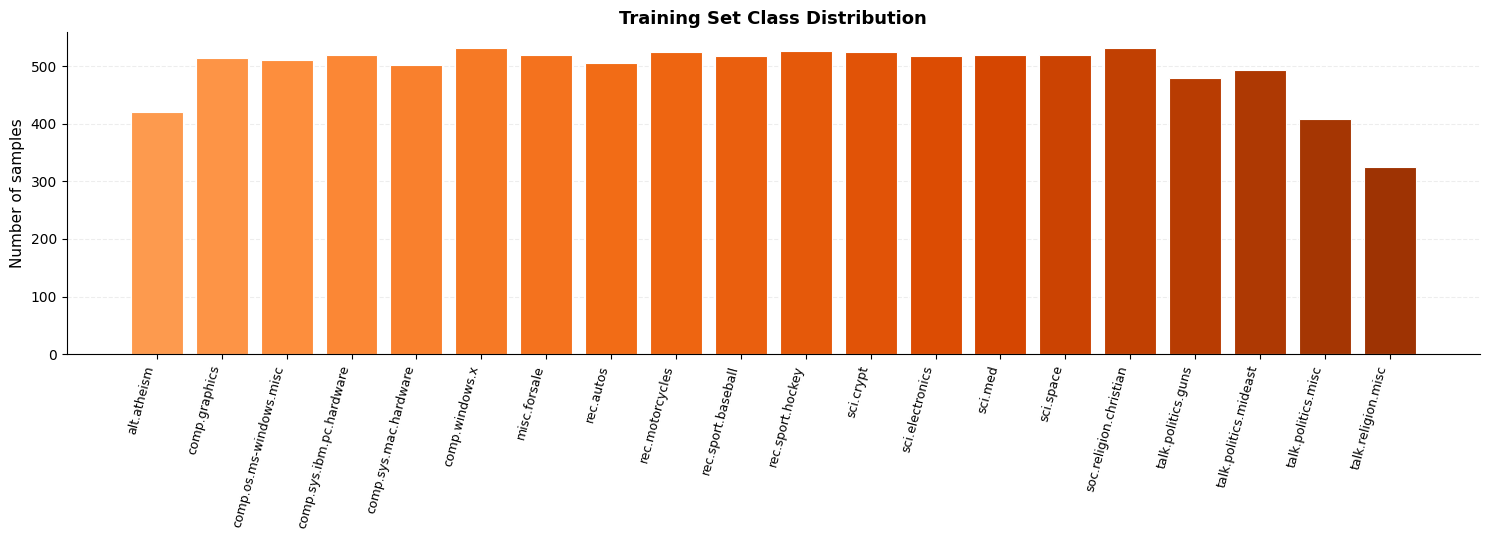

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5.5))

x = np.arange(len(label_counts))
y = label_counts.values
bars = ax.bar(x, y, color=plt.get_cmap("Oranges")(np.linspace(0.45, 0.9, len(y))),
              edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(label_counts.index, rotation=75, ha="right", fontsize=9)
ax.set_title("Training Set Class Distribution", fontsize=13, fontweight="semibold")
ax.set_ylabel("Number of samples", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

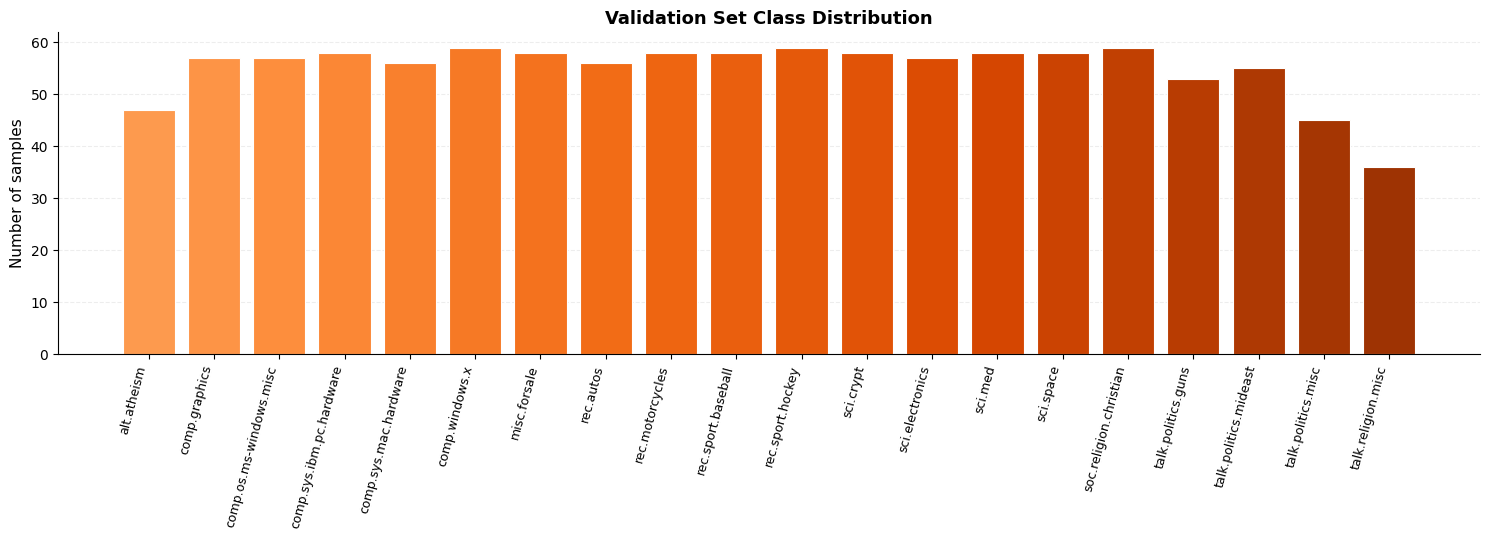

In [ ]:
val_label_counts = (
    val_df["label"]
    .value_counts()
    .sort_index()
    .rename(index=id2label)
)

fig, ax = plt.subplots(figsize=(15, 5.5))

x = np.arange(len(val_label_counts))
y = val_label_counts.values
bars = ax.bar(
    x, y,
    color=plt.get_cmap("Oranges")(np.linspace(0.45, 0.9, len(y))),
    edgecolor="white",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(val_label_counts.index, rotation=75, ha="right", fontsize=9)
ax.set_title("Validation Set Class Distribution", fontsize=13, fontweight="semibold")
ax.set_ylabel("Number of samples", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

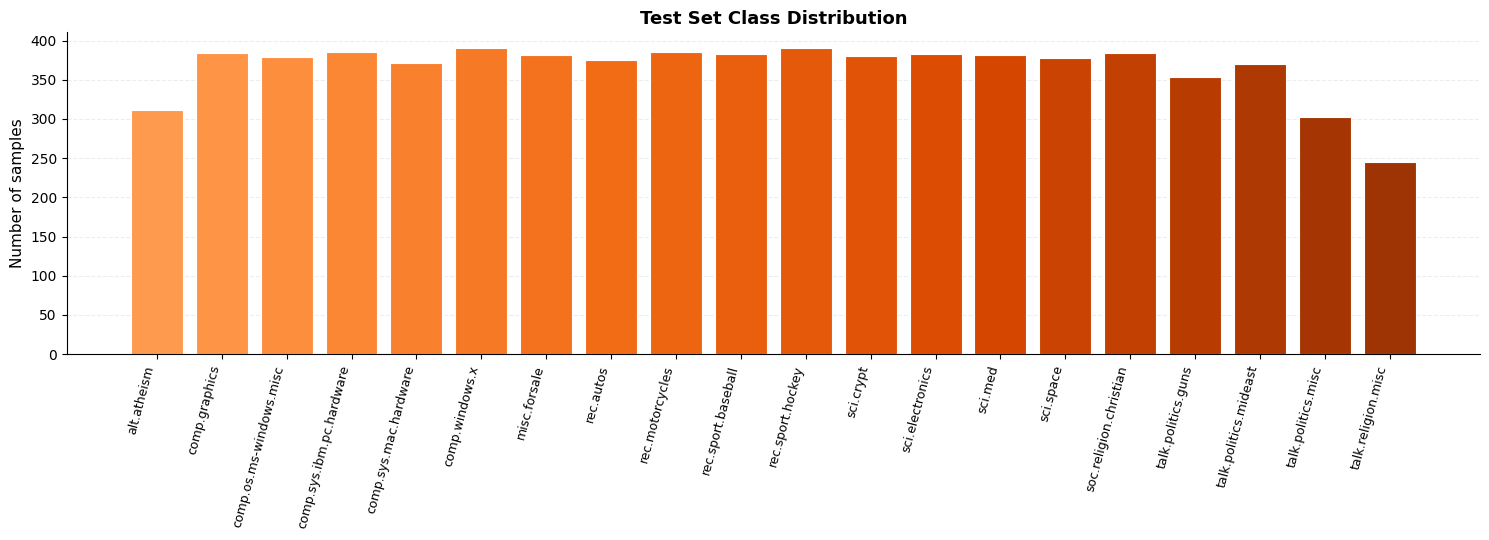

In [ ]:
test_label_counts = (
    test_df["label"]
    .value_counts()
    .sort_index()
    .rename(index=id2label)
)

fig, ax = plt.subplots(figsize=(15, 5.5))

x = np.arange(len(test_label_counts))
y = test_label_counts.values
bars = ax.bar(
    x, y,
    color=plt.get_cmap("Oranges")(np.linspace(0.45, 0.9, len(y))),
    edgecolor="white",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(test_label_counts.index, rotation=75, ha="right", fontsize=9)
ax.set_title("Test Set Class Distribution", fontsize=13, fontweight="semibold")
ax.set_ylabel("Number of samples", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

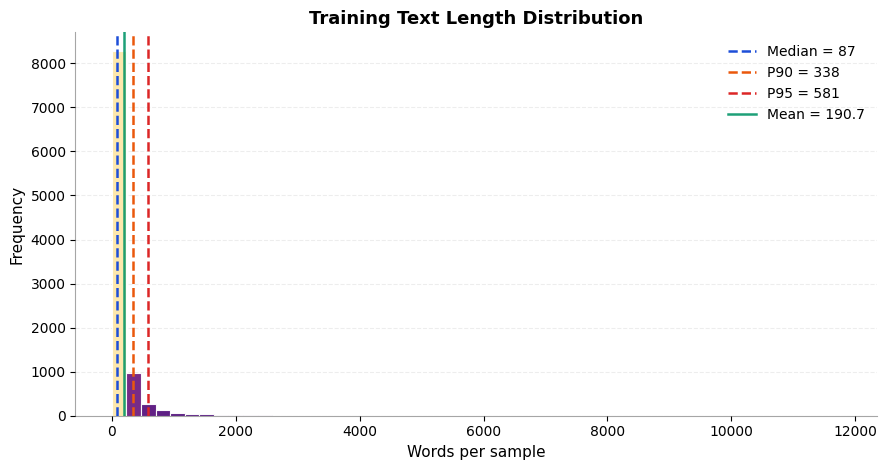

,text
count,9912.000000
mean,190.721651
std,537.837484
min,1.000000
50%,87.000000
90%,337.900000
95%,581.450000
99%,1765.120000
max,11765.000000


In [ ]:
train_word_lengths = train_df["text"].str.split().apply(len)

# Thống kê để annotate
p50 = train_word_lengths.quantile(0.50)
p90 = train_word_lengths.quantile(0.90)
p95 = train_word_lengths.quantile(0.95)
mean_val = train_word_lengths.mean()

fig, ax = plt.subplots(figsize=(9, 4.8))

counts, bins, patches = ax.hist(
    train_word_lengths,
    bins=50,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

# Gradient theo chiều cao cột
cmap = plt.get_cmap("magma")
if counts.max() > 0:
    for c, patch in zip(counts, patches):
        patch.set_facecolor(cmap(0.25 + 0.70 * (c / counts.max())))

# Percentile / mean lines
ax.axvline(p50, color="#1d4ed8", linestyle="--", linewidth=1.8, label=f"Median = {p50:.0f}")
ax.axvline(p90, color="#ea580c", linestyle="--", linewidth=1.8, label=f"P90 = {p90:.0f}")
ax.axvline(p95, color="#dc2626", linestyle="--", linewidth=1.8, label=f"P95 = {p95:.0f}")
ax.axvline(mean_val, color="#059669", linestyle="-", linewidth=1.8, alpha=0.9, label=f"Mean = {mean_val:.1f}")

ax.set_title("Training Text Length Distribution", fontsize=13, fontweight="semibold")
ax.set_xlabel("Words per sample", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

train_word_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

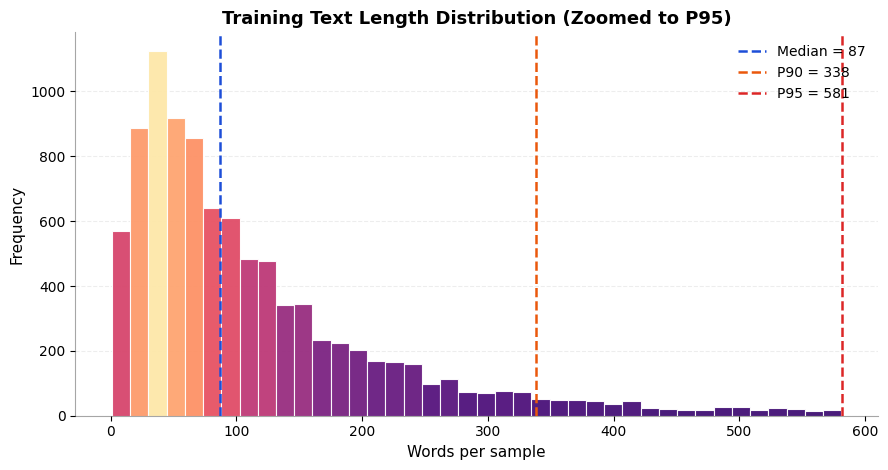

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))

zoom_lengths = train_word_lengths[train_word_lengths <= p95]

counts, bins, patches = ax.hist(
    zoom_lengths,
    bins=40,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

cmap = plt.get_cmap("magma")
if counts.max() > 0:
    for c, patch in zip(counts, patches):
        patch.set_facecolor(cmap(0.20 + 0.75 * (c / counts.max())))

ax.axvline(p50, color="#1d4ed8", linestyle="--", linewidth=1.8, label=f"Median = {p50:.0f}")
ax.axvline(p90, color="#ea580c", linestyle="--", linewidth=1.8, label=f"P90 = {p90:.0f}")
ax.axvline(p95, color="#dc2626", linestyle="--", linewidth=1.8, label=f"P95 = {p95:.0f}")

ax.set_title("Training Text Length Distribution (Zoomed to P95)", fontsize=13, fontweight="semibold")
ax.set_xlabel("Words per sample", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
sample_preview = train_df.sample(5, random_state=SEED).copy()
sample_preview["label_name"] = sample_preview["label"].map(id2label)
display(sample_preview[["label_name", "text"]])

,label_name,text
2830,comp.windows.x,--- Received from EEI.EEIIHY 353-1-2800455 93-...
7066,sci.med,I have heard that epileptic patients go into s...
360,talk.politics.guns,This is not borne out of reality; the old Sovi...
1479,alt.atheism,"How about the nickname Bake ""Flamethrower"" Tim..."
3034,sci.crypt,The original one-way encryption I put into Mul...


## 3. Utility functions dùng chung


In [ ]:
def compute_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_f1_macro"], marker="o", label="train_f1_macro")
    plt.plot(epochs, history["val_f1_macro"], marker="o", label="val_f1_macro")
    plt.title(f"{title} - Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, labels, title, figsize=(12, 10), cmap="magma"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Count", rotation=270, labelpad=15)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels)

    ax.set_title(title, fontsize=13, fontweight="semibold")
    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)

    threshold = cm.max() * 0.55 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, f"{val}",
                ha="center", va="center",
                fontsize=7,
                color="white" if val > threshold else "black"
            )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)

    plt.tight_layout()
    plt.show()

    return cm


def top_confusions_from_cm(cm, labels, top_k=10):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((labels[i], labels[j], int(cm[i, j])))
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:top_k]
    return pd.DataFrame(pairs, columns=["true_label", "predicted_label", "count"])

## 4. Chuẩn bị dữ liệu cho RNN (BiLSTM + pretrained GloVe)

Thiết kế:
- tokenize đơn giản bằng regex
- giới hạn độ dài câu ở `max_tokens_rnn`
- xây vocab từ train split
- nạp **GloVe 100d** để khởi tạo embedding matrix


In [ ]:
TOKEN_PATTERN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[^\w\s]")

def normalize_text_for_rnn(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_for_rnn(text: str):
    text = normalize_text_for_rnn(text)
    tokens = TOKEN_PATTERN.findall(text)
    return tokens[:CONFIG["max_tokens_rnn"]]


SPECIAL_TOKENS = ["<pad>", "<unk>"]
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1


def build_vocab(texts, max_vocab_size=30000):
    counter = Counter()
    for text in tqdm(texts, desc="Building vocab"):
        counter.update(tokenize_for_rnn(text))

    vocab_tokens = [tok for tok, _ in counter.most_common(max_vocab_size - len(SPECIAL_TOKENS))]
    itos = SPECIAL_TOKENS + vocab_tokens
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos, counter


stoi, itos, token_counter = build_vocab(train_df["text"], CONFIG["max_vocab_size"])
vocab_size = len(itos)
print("Vocab size:", vocab_size)
print("Most common tokens:", token_counter.most_common(20)[:10])

Building vocab:   0%|          | 0/9912 [00:00<?, ?it/s]

Vocab size: 20000
Most common tokens: [('.', 91869), ('-', 79396), ('the', 67244), (',', 61889), ('NUM', 52016), ('to', 33913), ('a', 29207), ('of', 28757), ('and', 25547), ('i', 21677)]


In [ ]:
%pip install -q gensim

In [ ]:
def build_embedding_matrix(itos, embedding_dim=100):
    matrix = np.random.normal(loc=0.0, scale=0.6, size=(len(itos), embedding_dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0

    used_pretrained = False
    matched = 0

    try:
        import gensim.downloader as api

        print("Downloading/loading pretrained GloVe vectors ...")
        glove = api.load("glove-wiki-gigaword-100")

        for idx, token in enumerate(tqdm(itos, desc="Matching GloVe vocab")):
            if token in glove:
                matrix[idx] = glove[token]
                matched += 1

        used_pretrained = True
        print(f"GloVe coverage over vocab: {matched}/{len(itos)} = {matched / len(itos):.2%}")

    except Exception as e:
        print("Could not load GloVe automatically. Falling back to random initialization.")
        print("Reason:", e)

    return matrix, used_pretrained, matched


embedding_matrix, used_pretrained_glove, matched_glove = build_embedding_matrix(
    itos,
    embedding_dim=CONFIG["embedding_dim"],
)

print("Using pretrained GloVe:", used_pretrained_glove)

Downloading/loading pretrained GloVe vectors ...
[==================================================] 100.0% 128.1/128.1MB downloaded


Matching GloVe vocab:   0%|          | 0/20000 [00:00<?, ?it/s]

GloVe coverage over vocab: 18579/20000 = 92.90%
Using pretrained GloVe: True


In [ ]:
class RNNTextDataset(Dataset):
    def __init__(self, df, stoi):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.stoi = stoi

    def __len__(self):
        return len(self.labels)

    def encode(self, text):
        tokens = tokenize_for_rnn(text)
        ids = [self.stoi.get(tok, UNK_IDX) for tok in tokens]
        if len(ids) == 0:
            ids = [UNK_IDX]
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        input_ids = self.encode(self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return {"input_ids": input_ids, "label": label}


def rnn_collate_fn(batch):
    input_ids = [x["input_ids"] for x in batch]
    labels = torch.stack([x["label"] for x in batch])
    lengths = torch.tensor([len(x) for x in input_ids], dtype=torch.long)

    padded = pad_sequence(input_ids, batch_first=True, padding_value=PAD_IDX)

    return {
        "input_ids": padded,
        "lengths": lengths,
        "labels": labels,
    }


train_rnn_ds = RNNTextDataset(train_df, stoi)
val_rnn_ds = RNNTextDataset(val_df, stoi)
test_rnn_ds = RNNTextDataset(test_df, stoi)

train_rnn_loader = DataLoader(
    train_rnn_ds,
    batch_size=CONFIG["rnn_batch_size"],
    shuffle=True,
    collate_fn=rnn_collate_fn,
)
val_rnn_loader = DataLoader(
    val_rnn_ds,
    batch_size=CONFIG["rnn_batch_size"],
    shuffle=False,
    collate_fn=rnn_collate_fn,
)
test_rnn_loader = DataLoader(
    test_rnn_ds,
    batch_size=CONFIG["rnn_batch_size"],
    shuffle=False,
    collate_fn=rnn_collate_fn,
)

batch_example = next(iter(train_rnn_loader))
{k: v.shape for k, v in batch_example.items()}

{'input_ids': torch.Size([128, 600]),
 'lengths': torch.Size([128]),
 'labels': torch.Size([128])}

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_labels,
        embedding_matrix=None,
        num_layers=1,
        dropout=0.3,
        pad_idx=0,
        trainable_embeddings=True,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))

        self.embedding.weight.requires_grad = trainable_embeddings

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)

        # hidden shape: [num_layers * num_directions, batch, hidden_dim]
        forward_last = hidden[-2]
        backward_last = hidden[-1]
        features = torch.cat((forward_last, backward_last), dim=1)
        features = self.dropout(features)
        logits = self.classifier(features)
        return logits


rnn_model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=CONFIG["embedding_dim"],
    hidden_dim=CONFIG["rnn_hidden_dim"],
    num_labels=num_labels,
    embedding_matrix=embedding_matrix,
    num_layers=CONFIG["rnn_num_layers"],
    dropout=CONFIG["rnn_dropout"],
    pad_idx=PAD_IDX,
    trainable_embeddings=True,
).to(DEVICE)

print(rnn_model)
print("Trainable parameters:", f"{count_trainable_parameters(rnn_model):,}")

BiLSTMClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=20, bias=True)
)
Trainable parameters: 2,240,660


RNN Epoch 1/8:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 1: train_loss=2.8409, val_loss=2.4667, train_acc=0.1127, val_acc=0.1788, train_f1=0.0909, val_f1=0.1076


RNN Epoch 2/8:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 2: train_loss=2.3401, val_loss=2.2478, train_acc=0.2172, val_acc=0.2359, train_f1=0.1816, val_f1=0.1812


RNN Epoch 3/8:   0%|          | 0/78 [00:00<?, ?it/s]

...

Epoch 6: train_loss=1.5492, val_loss=1.6883, train_acc=0.4633, val_acc=0.4047, train_f1=0.4336, val_f1=0.3767


RNN Epoch 7/8:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 7: train_loss=1.3618, val_loss=1.5091, train_acc=0.5270, val_acc=0.4900, train_f1=0.5007, val_f1=0.4594


RNN Epoch 8/8:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 8: train_loss=1.1727, val_loss=1.4470, train_acc=0.5986, val_acc=0.4964, train_f1=0.5748, val_f1=0.4642


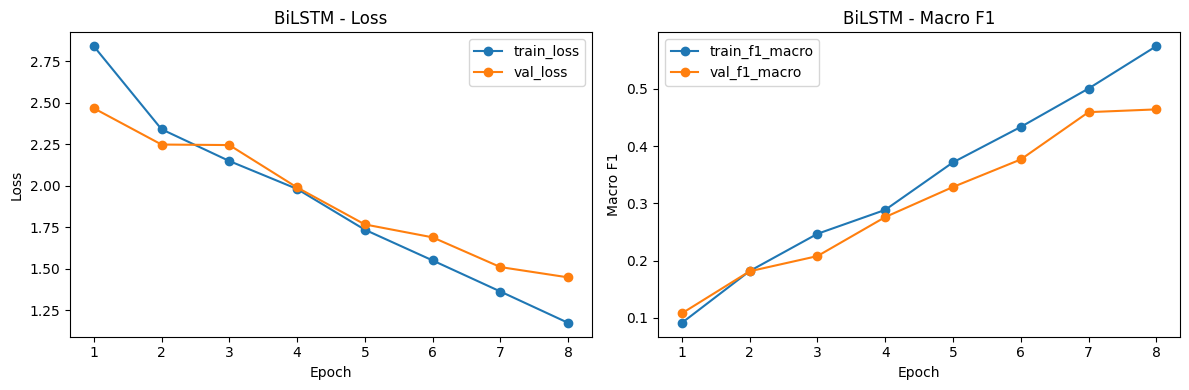

In [ ]:
def evaluate_rnn(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            lengths = batch["lengths"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, all_labels, all_preds


def train_rnn(model, train_loader, val_loader, config):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["rnn_lr"],
        weight_decay=config["rnn_weight_decay"],
    )

    best_state = None
    best_val_f1 = -np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1_macro": [],
        "val_f1_macro": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    start_time = time.time()

    for epoch in range(1, config["rnn_epochs"] + 1):
        model.train()
        total_loss = 0.0
        train_preds = []
        train_labels = []

        loop = tqdm(train_loader, desc=f"RNN Epoch {epoch}/{config['rnn_epochs']}")
        for batch in loop:
            input_ids = batch["input_ids"].to(DEVICE)
            lengths = batch["lengths"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)

            train_preds.extend(preds.detach().cpu().numpy().tolist())
            train_labels.extend(labels.detach().cpu().numpy().tolist())

            loop.set_postfix(loss=float(loss.item()))

        train_loss = total_loss / len(train_loader.dataset)
        train_metrics = compute_metrics(train_labels, train_preds)

        val_loss, val_metrics, _, _ = evaluate_rnn(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1_macro"].append(train_metrics["f1_macro"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_metrics['accuracy']:.4f}, val_acc={val_metrics['accuracy']:.4f}, "
            f"train_f1={train_metrics['f1_macro']:.4f}, val_f1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["rnn_patience"]:
                print("Early stopping triggered for RNN.")
                break

    training_time = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, training_time


rnn_model, rnn_history, rnn_training_time = train_rnn(
    rnn_model,
    train_rnn_loader,
    val_rnn_loader,
    CONFIG,
)

plot_training_history(rnn_history, "BiLSTM")

In [ ]:
rnn_criterion = nn.CrossEntropyLoss()

rnn_val_loss, rnn_val_metrics, rnn_val_true, rnn_val_pred = evaluate_rnn(
    rnn_model, val_rnn_loader, rnn_criterion
)
rnn_test_loss, rnn_test_metrics, rnn_test_true, rnn_test_pred = evaluate_rnn(
    rnn_model, test_rnn_loader, rnn_criterion
)

print("RNN validation metrics:", json.dumps(rnn_val_metrics, indent=2))
print("RNN test metrics:", json.dumps(rnn_test_metrics, indent=2))

rnn_report_df = pd.DataFrame(
    classification_report(
        rnn_test_true,
        rnn_test_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
).T

display(rnn_report_df.head())

RNN validation metrics: {
  "accuracy": 0.49637023593466423,
  "precision_macro": 0.4840483832415969,
  "recall_macro": 0.48550940140147325,
  "f1_macro": 0.46424345356165897,
  "precision_weighted": 0.49786397238149344,
  "recall_weighted": 0.49637023593466423,
  "f1_weighted": 0.47619779288297737
}
RNN test metrics: {
  "accuracy": 0.48530818641519746,
  "precision_macro": 0.4893534250705227,
  "recall_macro": 0.476552277828279,
  "f1_macro": 0.4487720240804836,
  "precision_weighted": 0.496427655380564,
  "recall_weighted": 0.48530818641519746,
  "f1_weighted": 0.4583608918893945
}


,precision,recall,f1-score,support
alt.atheism,0.312500,0.305466,0.308943,311.0
comp.graphics,0.355828,0.151042,0.212066,384.0
comp.os.ms-windows.misc,0.493734,0.519789,0.506427,379.0
comp.sys.ibm.pc.hardware,0.421941,0.259067,0.321027,386.0
comp.sys.mac.hardware,0.459302,0.425876,0.441958,371.0


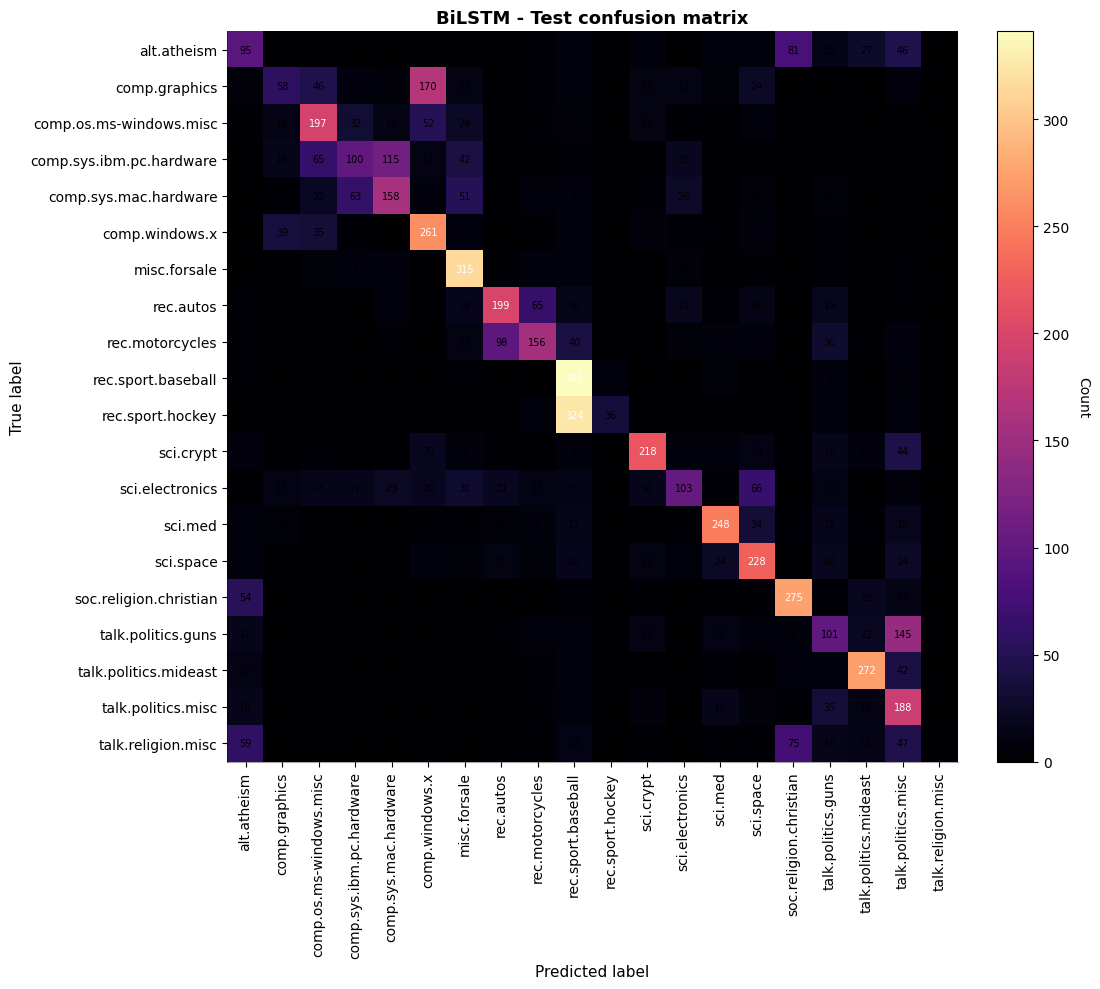

,true_label,predicted_label,count
0,rec.sport.hockey,rec.sport.baseball,324
1,comp.graphics,comp.windows.x,170
2,talk.politics.guns,talk.politics.misc,145
3,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,115
4,rec.motorcycles,rec.autos,98
5,alt.atheism,soc.religion.christian,81
6,talk.religion.misc,soc.religion.christian,75
7,sci.electronics,sci.space,66
8,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,65
9,rec.autos,rec.motorcycles,65


In [ ]:
rnn_cm = plot_confusion(
    rnn_test_true,
    rnn_test_pred,
    label_names,
    title="BiLSTM - Test confusion matrix",
)

display(top_confusions_from_cm(rnn_cm, label_names, top_k=15))

## 5. Chuẩn bị dữ liệu cho Transformer (DistilBERT)

Chọn **DistilBERT** vì đây là một Transformer nhẹ hơn BERT-base

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["transformer_ckpt"])

class TransformerTextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_attention_mask=True,
        )
        item = {k: torch.tensor(v, dtype=torch.long) for k, v in encoded.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class HFPadCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        labels = torch.tensor([f["labels"] for f in features], dtype=torch.long)
        inputs = [{k: v for k, v in f.items() if k != "labels"} for f in features]
        batch = self.tokenizer.pad(inputs, return_tensors="pt")
        batch["labels"] = labels
        return batch


train_tf_ds = TransformerTextDataset(
    train_df, tokenizer, CONFIG["max_length_transformer"]
)
val_tf_ds = TransformerTextDataset(
    val_df, tokenizer, CONFIG["max_length_transformer"]
)
test_tf_ds = TransformerTextDataset(
    test_df, tokenizer, CONFIG["max_length_transformer"]
)

tf_collator = HFPadCollator(tokenizer)

train_tf_loader = DataLoader(
    train_tf_ds,
    batch_size=CONFIG["transformer_batch_size"],
    shuffle=True,
    collate_fn=tf_collator,
)
val_tf_loader = DataLoader(
    val_tf_ds,
    batch_size=CONFIG["transformer_batch_size"],
    shuffle=False,
    collate_fn=tf_collator,
)
test_tf_loader = DataLoader(
    test_tf_ds,
    batch_size=CONFIG["transformer_batch_size"],
    shuffle=False,
    collate_fn=tf_collator,
)

batch_example_tf = next(iter(train_tf_loader))
{k: v.shape for k, v in batch_example_tf.items()}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': torch.Size([16, 256]),
 'token_type_ids': torch.Size([16, 256]),
 'attention_mask': torch.Size([16, 256]),
 'labels': torch.Size([16])}

In [ ]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["transformer_ckpt"],
    num_labels=num_labels,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()},
).to(DEVICE)

print(transformer_model.__class__.__name__)
print("Trainable parameters:", f"{count_trainable_parameters(transformer_model):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification
Trainable parameters: 66,968,852


Transformer Epoch 1/3:   0%|          | 0/620 [00:00<?, ?it/s]

Epoch 1: train_loss=1.8249, val_loss=1.0856, train_acc=0.5104, val_acc=0.6779, train_f1=0.4838, val_f1=0.6467


Transformer Epoch 2/3:   0%|          | 0/620 [00:00<?, ?it/s]

Epoch 2: train_loss=0.8561, val_loss=0.9067, train_acc=0.7534, val_acc=0.7296, train_f1=0.7270, val_f1=0.7055


Transformer Epoch 3/3:   0%|          | 0/620 [00:00<?, ?it/s]

Epoch 3: train_loss=0.6264, val_loss=0.8706, train_acc=0.8215, val_acc=0.7387, train_f1=0.7984, val_f1=0.7152


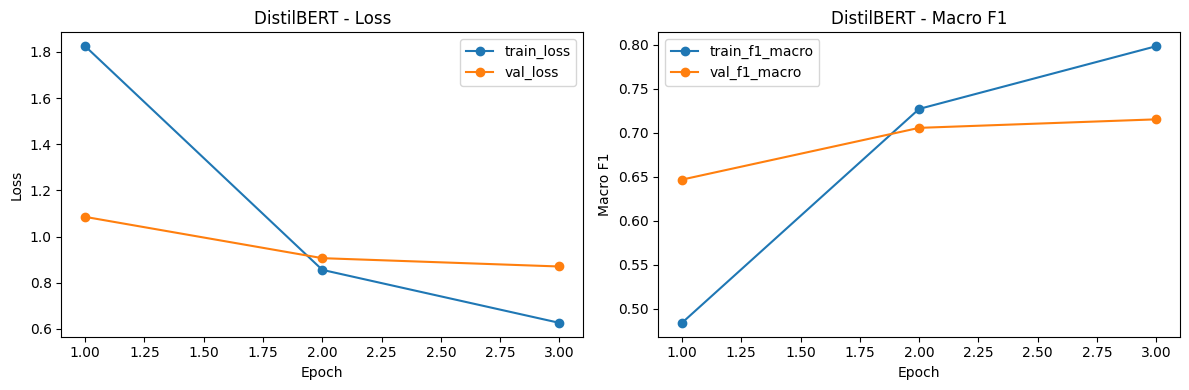

In [ ]:
def evaluate_transformer(model, dataloader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item() * batch["labels"].size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(batch["labels"].cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, all_labels, all_preds


def train_transformer(model, train_loader, val_loader, config):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["transformer_lr"],
        weight_decay=config["transformer_weight_decay"],
    )

    total_steps = len(train_loader) * config["transformer_epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])

    scheduler = get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    best_state = None
    best_val_f1 = -np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1_macro": [],
        "val_f1_macro": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    start_time = time.time()

    for epoch in range(1, config["transformer_epochs"] + 1):
        model.train()
        total_loss = 0.0
        train_preds = []
        train_labels = []

        loop = tqdm(train_loader, desc=f"Transformer Epoch {epoch}/{config['transformer_epochs']}")
        for batch in loop:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * batch["labels"].size(0)
            preds = torch.argmax(logits, dim=1)

            train_preds.extend(preds.detach().cpu().numpy().tolist())
            train_labels.extend(batch["labels"].detach().cpu().numpy().tolist())

            loop.set_postfix(loss=float(loss.item()))

        train_loss = total_loss / len(train_loader.dataset)
        train_metrics = compute_metrics(train_labels, train_preds)

        val_loss, val_metrics, _, _ = evaluate_transformer(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1_macro"].append(train_metrics["f1_macro"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_metrics['accuracy']:.4f}, val_acc={val_metrics['accuracy']:.4f}, "
            f"train_f1={train_metrics['f1_macro']:.4f}, val_f1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["transformer_patience"]:
                print("Early stopping triggered for Transformer.")
                break

    training_time = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, training_time


transformer_model, transformer_history, transformer_training_time = train_transformer(
    transformer_model,
    train_tf_loader,
    val_tf_loader,
    CONFIG,
)

plot_training_history(transformer_history, "DistilBERT")

In [ ]:
tf_val_loss, tf_val_metrics, tf_val_true, tf_val_pred = evaluate_transformer(
    transformer_model, val_tf_loader
)
tf_test_loss, tf_test_metrics, tf_test_true, tf_test_pred = evaluate_transformer(
    transformer_model, test_tf_loader
)

print("Transformer validation metrics:", json.dumps(tf_val_metrics, indent=2))
print("Transformer test metrics:", json.dumps(tf_test_metrics, indent=2))

tf_report_df = pd.DataFrame(
    classification_report(
        tf_test_true,
        tf_test_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
).T

display(tf_report_df.head())

Transformer validation metrics: {
  "accuracy": 0.7386569872958257,
  "precision_macro": 0.7213484948319419,
  "recall_macro": 0.7235179380921094,
  "f1_macro": 0.7151859793376412,
  "precision_weighted": 0.7332556172765566,
  "recall_weighted": 0.7386569872958257,
  "f1_weighted": 0.7301648491963295
}
Transformer test metrics: {
  "accuracy": 0.7146371463714637,
  "precision_macro": 0.6988143357101685,
  "recall_macro": 0.6976051650759252,
  "f1_macro": 0.689111056269891,
  "precision_weighted": 0.7107039016195286,
  "recall_weighted": 0.7146371463714637,
  "f1_weighted": 0.7058631629411126
}


,precision,recall,f1-score,support
alt.atheism,0.405263,0.495177,0.445731,311.0
comp.graphics,0.725543,0.695312,0.710106,384.0
comp.os.ms-windows.misc,0.657360,0.683377,0.670116,379.0
comp.sys.ibm.pc.hardware,0.623223,0.681347,0.650990,386.0
comp.sys.mac.hardware,0.720461,0.673854,0.696379,371.0


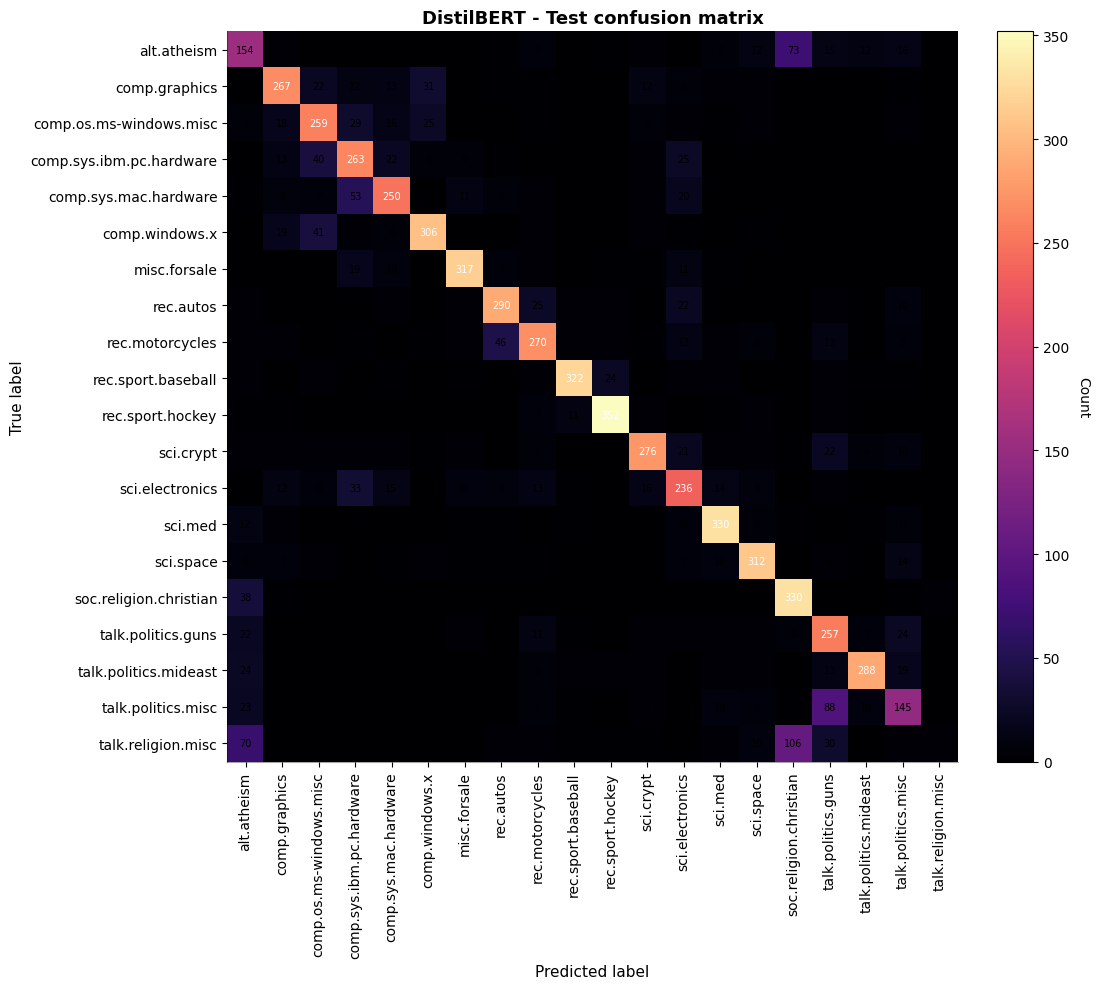

,true_label,predicted_label,count
0,talk.religion.misc,soc.religion.christian,106
1,talk.politics.misc,talk.politics.guns,88
2,alt.atheism,soc.religion.christian,73
3,talk.religion.misc,alt.atheism,70
4,comp.sys.mac.hardware,comp.sys.ibm.pc.hardware,53
5,rec.motorcycles,rec.autos,46
6,comp.windows.x,comp.os.ms-windows.misc,41
7,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,40
8,soc.religion.christian,alt.atheism,38
9,sci.electronics,comp.sys.ibm.pc.hardware,33


In [ ]:
tf_cm = plot_confusion(
    tf_test_true,
    tf_test_pred,
    label_names,
    title="DistilBERT - Test confusion matrix",
)

display(top_confusions_from_cm(tf_cm, label_names, top_k=15))

## 6. So sánh kết quả cuối cùng

Bảng dưới đây so sánh các chỉ số:
- accuracy
- macro F1
- weighted F1
- số tham số trainable
- thời gian huấn luyện


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "BiLSTM + GloVe",
        "group": "RNN",
        "test_accuracy": rnn_test_metrics["accuracy"],
        "test_f1_macro": rnn_test_metrics["f1_macro"],
        "test_f1_weighted": rnn_test_metrics["f1_weighted"],
        "val_accuracy_best": rnn_val_metrics["accuracy"],
        "val_f1_macro_best": rnn_val_metrics["f1_macro"],
        "trainable_params": count_trainable_parameters(rnn_model),
        "training_time_minutes": rnn_training_time / 60,
        "used_pretrained_component": "GloVe embeddings" if used_pretrained_glove else "Random embeddings fallback",
    },
    {
        "model": "DistilBERT",
        "group": "Transformer",
        "test_accuracy": tf_test_metrics["accuracy"],
        "test_f1_macro": tf_test_metrics["f1_macro"],
        "test_f1_weighted": tf_test_metrics["f1_weighted"],
        "val_accuracy_best": tf_val_metrics["accuracy"],
        "val_f1_macro_best": tf_val_metrics["f1_macro"],
        "trainable_params": count_trainable_parameters(transformer_model),
        "training_time_minutes": transformer_training_time / 60,
        "used_pretrained_component": CONFIG["transformer_ckpt"],
    },
])

comparison_df = comparison_df.sort_values(by="test_f1_macro", ascending=False).reset_index(drop=True)
display(comparison_df)

comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / "model_comparison.csv")

,model,group,test_accuracy,test_f1_macro,test_f1_weighted,val_accuracy_best,val_f1_macro_best,trainable_params,training_time_minutes,used_pretrained_component
0,DistilBERT,Transformer,0.714637,0.689111,0.705863,0.738657,0.715186,66968852,13.146554,distilbert-base-uncased
1,BiLSTM + GloVe,RNN,0.485308,0.448772,0.458361,0.496370,0.464243,2240660,1.536797,GloVe embeddings


Saved: results_text_assignment1/model_comparison.csv


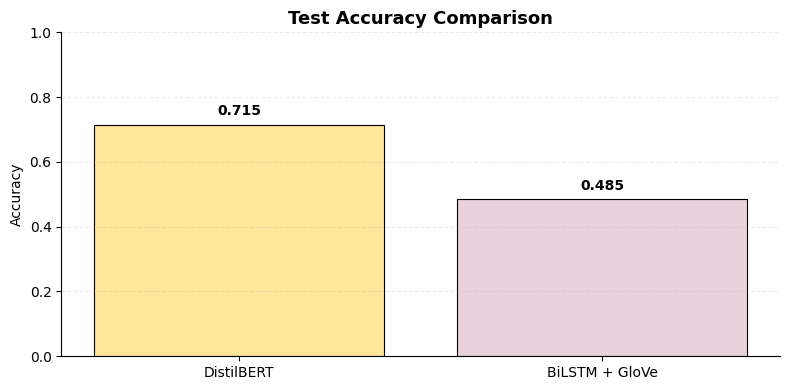

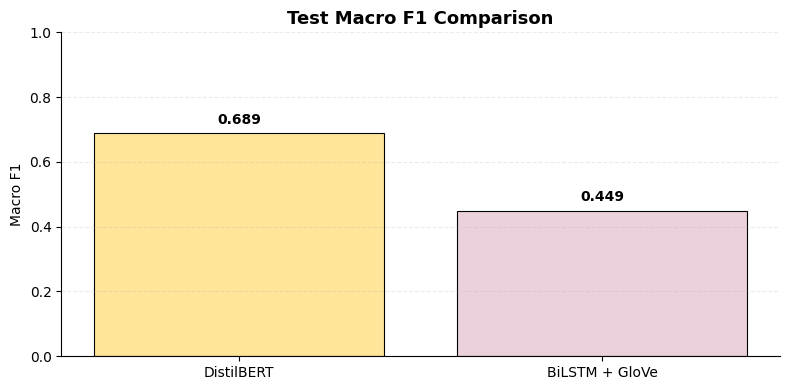

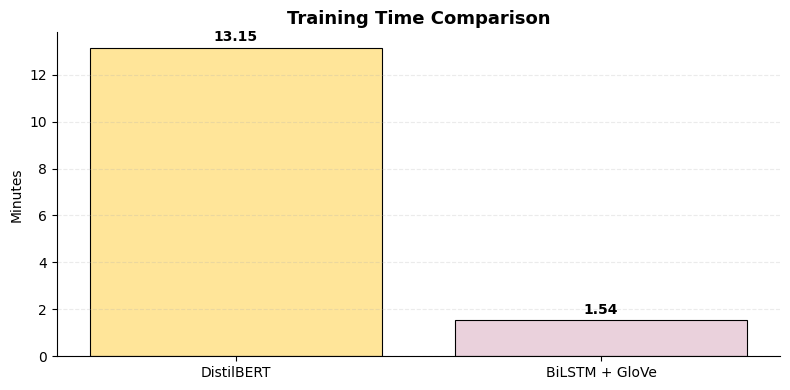

In [ ]:
plt.figure(figsize=(8, 4))
colors = ["#FFE599", "#EAD1DC"][:len(comparison_df)]
bars = plt.bar(comparison_df["model"], comparison_df["test_accuracy"], color=colors, edgecolor="black", linewidth=0.8)
plt.title("Test Accuracy Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.25)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
colors = ["#FFE599", "#EAD1DC"][:len(comparison_df)]
bars = plt.bar(comparison_df["model"], comparison_df["test_f1_macro"], color=colors, edgecolor="black", linewidth=0.8)
plt.title("Test Macro F1 Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.25)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
colors = ["#FFE599", "#EAD1DC"][:len(comparison_df)]
bars = plt.bar(comparison_df["model"], comparison_df["training_time_minutes"], color=colors, edgecolor="black", linewidth=0.8)
plt.title("Training Time Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Minutes")
plt.grid(axis="y", linestyle="--", alpha=0.25)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.15, f"{h:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
def collect_misclassified_examples(df, y_true, y_pred, id2label, top_n=10):
    errors = []
    for idx, (true_id, pred_id) in enumerate(zip(y_true, y_pred)):
        if true_id != pred_id:
            errors.append({
                "text": df.iloc[idx]["text"],
                "true_label": id2label[true_id],
                "predicted_label": id2label[pred_id],
            })
    return pd.DataFrame(errors[:top_n])

rnn_errors = collect_misclassified_examples(test_df, rnn_test_true, rnn_test_pred, id2label, top_n=8)
tf_errors = collect_misclassified_examples(test_df, tf_test_true, tf_test_pred, id2label, top_n=8)

print("BiLSTM misclassified examples:")
display(rnn_errors)

print("DistilBERT misclassified examples:")
display(tf_errors)

BiLSTM misclassified examples:


,text,true_label,predicted_label
0,I am a little confused on all of the models of the 88-89 bonnevilles. I have heard of the LE SE LSE SSE SSEI. Could someone tell me the differences are far as features or performance. I am also curious to know what the book value is for prefereably the 89 model. And how much less than book value can you usually get them for. In other words how much are they in demand this time of year. I have heard that the mid-spring early summer is the best time to buy.,rec.autos,comp.sys.mac.hardware
1,I've just spent two solid months arguing that no such thing as an objective moral system exists.,talk.religion.misc,alt.atheism
2,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPerfect). However, some one wiped out the EXE file, and she has not been able to restore it. There are no distributors of the package in South Africa. I would appreciate it, if some one could email me the file, or at least tell me where I could get it from. My email address is fortmann@superbowl.und.ac.za or fortmann@shrike.und.ac.za Many thanks.",soc.religion.christian,sci.crypt
3,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a religion- it would seem to be dependent solely on the individual, as well as individually-created. And since Christians have failed to show us how there way of life is in any wy better than ours, I do not see why the attempt to try it is necessary, or even particularly attractive. Well, we will nerver know for sure if we were told the truth or not, but at the very least there is a bit more evidence pointing to the fact that, say, there was a military conflict in Vietnam 25 years ago, then there is a supernatural diety who wants us to live a certain way. The fact that Jesus warned against it means nothing. *I* warn against it too. Big deal. This is not true. The first two choices here (life and death) are scantily documented, and the last one is total malarky unless one uses the Bible, and that is totally circular. Perhaps it be better to use the imagination, or one's ignorance. Someone else will address this I'm sure, and refer you to plenty of documentation... How is this? There is nothing more disgusting than Christian attempts to manipulate/interpret the Old Testament as being filled with signs for the coming of Christ. Every little reference to a stick or bit of wood is autmoatically interpreted as the Cross. What a miscarriage of philology. Well, since we have skeptical hearts (thank goodness,) there is no way to get into us. Here we have the irreconcilable difference: Christians glorify exactly what we tend to despise or snub: trust/belief/faith without knowledge. If I am lucky one day and I happen to be thinking of God at the same time my enkephalins go up, then I may associate this as a sign of God (it will ""feel"" right, and I will trust without knowing). Maybe. Religosity does not seem to be anything that is conclusively arrived at, but rather it seems to be more of a sudden affliction... I believe many of us were willing to die for what we believed, many of us were not. The question is, is suchg an attitude reflective of a _correct_ or healthy morality. IT would seem not to be. The same thing could reflect fanaticism, for example, and is any case an expression of simple selfishness. -- --Adam",alt.atheism,soc.religion.christian
4,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA's 8/(16?) But it still moves it at about the speed as the ISA bus. I think that's either 8 or 10 mhz. The local bus designs also move 32 bits like the EISA, but they move the data at the cpu speed, up to 40 mhz. So, on a 33mhz cpu, the local bus is moving 32bit data at 33 mhz, and the EISA is moving 32bit da

DistilBERT misclassified examples:


,text,true_label,predicted_label
0,"In a word, yes.",alt.atheism,talk.politics.misc
1,I've just spent two solid months arguing that no such thing as an objective moral system exists.,talk.religion.misc,alt.atheism
2,"Dishonest money dwindles away, but he who gathers money little by little makes it grow. Proverbs 13:11",soc.religion.christian,alt.atheism
3,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPerfect). However, some one wiped out the EXE file, and she has not been able to restore it. There are no distributors of the package in South Africa. I would appreciate it, if some one could email me the file, or at least tell me where I could get it from. My email address is fortmann@superbowl.und.ac.za or fortmann@shrike.und.ac.za Many thanks.",soc.religion.christian,comp.os.ms-windows.misc
4,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk.",rec.motorcycles,talk.politics.guns
5,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a religion- it would seem to be dependent solely on the individual, as well as individually-created. And since Christians have failed to show us how there way of life is in any wy better than ours, I do not see why the attempt to try it is necessary, or even particularly attractive. Well, we will nerver know for sure if we were told the truth or not, but at the very least there is a bit more evidence pointing to the fact that, say, there was a military conflict in Vietnam 25 years ago, then there is a supernatural diety who wants us to live a certain way. The fact that Jesus warned against it means nothing. *I* warn against it too. Big deal. This is not true. The first two choices here (life and death) are scantily documented, and the last one is total malarky unless one uses the Bible, and that is totally circular. Perhaps it be better to use the imagination, or one's ignorance. Someone else will address this I'm sure, and refer you to plenty of documentation... How is this? There is nothing more disgusting than Christian attempts to manipulate/interpret the Old Testament as being filled with signs for the coming of Christ. Every little reference to a stick or bit of wood is autmoatically interpreted as the Cross. What a miscarriage of philology. Well, since we have skeptical hearts (thank goodness,) there is no way to get into us. Here we have the irreconcilable difference: Christians glorify exactly what we tend to despise or snub: trust/belief/faith without knowledge. If I am lucky one day and I happen to be thinking of God at the same time my enkephalins go up, then I may associate this as a sign of God (it will ""feel"" right, and I will trust without knowing). Maybe. Religosity does not seem to be anything that is conclusively arrived at, but rather it seems to be more of a sudden affliction... I believe many of us were willing to die for what we believed, many of us were not. The question is, is suchg an attitude reflective of a _correct_ or healthy morality. IT would seem not to be. The same thing could reflect fanaticism, for example, and is any case an expression of simple selfishness. -- --Adam",alt.atheism,soc.religion.christian
6,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA's 8/(16?) But it still moves it at about the speed as the ISA bus. I think that's either 8 or 10 mhz. The local bus designs also move 32 bits like the EISA, but they move the data at the cpu speed, up to 40 mhz. So, on a 33mhz cpu, the local bus is moving 32bit data at 33 mhz, and the EISA is moving 32bit data at 8 or 10 mhz. So the local bus should be 3 to 4 times faster than EISA on a 33 mhz cpu

In [ ]:
summary = comparison_df.loc[0].to_dict()
winner = summary["model"]

print(f"Best model by test macro F1: {winner}")
print()
print("Quick interpretation:")
if winner == "DistilBERT":
    print("- Transformer is stronger on semantic modeling and long-range dependencies.")
    print("- BiLSTM is usually lighter to explain and faster to iterate on.")
else:
    print("- BiLSTM performed strongly on this run, possibly due to effective word embeddings and dataset properties.")
    print("- Transformer may still be preferable if further tuning/resources are available.")

print()
print("Suggested discussion points for the report:")
print("1. Accuracy vs macro F1: discuss not only overall correctness but also balance across classes.")
print("2. Efficiency vs performance: compare quality against training time and parameter count.")
print("3. Error analysis: inspect confusing topic pairs from the confusion matrix.")
print("4. Pretrained component effect: GloVe vs pretrained Transformer encoder.")

Best model by test macro F1: DistilBERT

Quick interpretation:
- Transformer is stronger on semantic modeling and long-range dependencies.
- BiLSTM is usually lighter to explain and faster to iterate on.

Suggested discussion points for the report:
1. Accuracy vs macro F1: discuss not only overall correctness but also balance across classes.
2. Efficiency vs performance: compare quality against training time and parameter count.
3. Error analysis: inspect confusing topic pairs from the confusion matrix.
4. Pretrained component effect: GloVe vs pretrained Transformer encoder.


In [ ]:
# Save detailed reports for later use in the Markdown report / slides
rnn_report_df.to_csv(RESULTS_DIR / "bilstm_classification_report.csv")
tf_report_df.to_csv(RESULTS_DIR / "distilbert_classification_report.csv")

with open(RESULTS_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "rnn_val_metrics": rnn_val_metrics,
        "rnn_test_metrics": rnn_test_metrics,
        "transformer_val_metrics": tf_val_metrics,
        "transformer_test_metrics": tf_test_metrics,
        "config": CONFIG,
    }, f, indent=2)

print("Saved detailed outputs to:", RESULTS_DIR.resolve())

Saved detailed outputs to: /content/results_text_assignment1


## 6.1. Phần mở rộng

Các phần dưới đây:
- **Efficiency**: thêm benchmark thời gian suy luận / throughput.
- **Ensemble**: kết hợp RNN + Transformer để so sánh với từng mô hình đơn lẻ.
- **Calibration**: đo độ tin cậy dự đoán bằng ECE + reliability diagram.
- **Robustness**: thử nhiễu/corruption nhẹ trên văn bản để xem mô hình giảm chất lượng ra sao.


In [ ]:
# ==== Helper functions for enhancement experiments ====

@torch.no_grad()
def collect_rnn_logits(model, dataloader):
    model.eval()
    all_logits = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        lengths = batch["lengths"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = model(input_ids, lengths)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)


@torch.no_grad()
def collect_transformer_logits(model, dataloader):
    model.eval()
    all_logits = []
    all_labels = []

    for batch in dataloader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        all_logits.append(outputs.logits.cpu())
        all_labels.append(batch["labels"].cpu())

    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)


def logits_to_probs(logits_tensor):
    return torch.softmax(logits_tensor, dim=1).cpu().numpy()


def search_best_ensemble_alpha(y_true, rnn_probs, tf_probs, alphas=None):
    if alphas is None:
        alphas = np.linspace(0.0, 1.0, 11)

    rows = []
    for alpha_tf in alphas:
        ensemble_probs = (1.0 - alpha_tf) * rnn_probs + alpha_tf * tf_probs
        ensemble_pred = ensemble_probs.argmax(axis=1)
        metrics = compute_metrics(y_true, ensemble_pred)
        rows.append({
            "alpha_transformer": alpha_tf,
            "alpha_rnn": 1.0 - alpha_tf,
            **metrics,
        })

    result_df = pd.DataFrame(rows).sort_values(
        by=["f1_macro", "accuracy"], ascending=False
    ).reset_index(drop=True)
    best_row = result_df.iloc[0].to_dict()
    return best_row, result_df


def benchmark_inference(model, dataloader, model_type, warmup_batches=5, measure_batches=30):
    model.eval()
    batch_times = []
    total_samples = 0

    for batch_idx, batch in enumerate(dataloader):
        if batch_idx >= warmup_batches + measure_batches:
            break

        if model_type == "rnn":
            input_ids = batch["input_ids"].to(DEVICE)
            lengths = batch["lengths"].to(DEVICE)
            labels = batch["labels"]
            run_fn = lambda: model(input_ids, lengths)
        else:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = batch["labels"]
            run_fn = lambda: model(**batch).logits

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()

        with torch.no_grad():
            _ = run_fn()

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        if batch_idx >= warmup_batches:
            batch_times.append(elapsed)
            total_samples += int(labels.size(0))

    avg_batch_time_ms = 1000 * np.mean(batch_times)
    throughput = total_samples / np.sum(batch_times)
    latency_per_sample_ms = 1000 / throughput

    return {
        "avg_batch_time_ms": avg_batch_time_ms,
        "throughput_samples_per_sec": throughput,
        "latency_per_sample_ms": latency_per_sample_ms,
        "measured_batches": len(batch_times),
    }


def compute_ece(y_true, probs, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if mask.sum() == 0:
            rows.append({
                "bin_left": left,
                "bin_right": right,
                "count": 0,
                "avg_confidence": np.nan,
                "accuracy": np.nan,
            })
            continue

        bin_conf = confidences[mask].mean()
        bin_acc = accuracies[mask].mean()
        weight = mask.mean()
        ece += weight * abs(bin_acc - bin_conf)

        rows.append({
            "bin_left": left,
            "bin_right": right,
            "count": int(mask.sum()),
            "avg_confidence": float(bin_conf),
            "accuracy": float(bin_acc),
        })

    return float(ece), pd.DataFrame(rows)


def plot_reliability_diagram(calibration_df, title, cmap="magma"):
    plot_df = calibration_df.dropna().copy()
    centers = (plot_df["bin_left"] + plot_df["bin_right"]) / 2

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")

    bars = plt.bar(
        centers,
        plot_df["accuracy"],
        width=0.9 / len(plot_df),
        alpha=0.85,
        label="accuracy per bin",
    )

    cmap_obj = plt.get_cmap(cmap)
    max_acc = plot_df["accuracy"].max() if len(plot_df) > 0 else 1.0
    for bar, acc in zip(bars, plot_df["accuracy"]):
        color_val = 0.25 + 0.70 * (acc / max_acc) if max_acc > 0 else 0.4
        bar.set_facecolor(cmap_obj(color_val))
        bar.set_edgecolor("white")
        bar.set_linewidth(0.8)

    plt.plot(
        centers,
        plot_df["avg_confidence"],
        marker="o",
        label="avg confidence",
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def random_char_swap(token, rng):
    if len(token) < 4:
        return token
    idx = rng.integers(0, len(token) - 1)
    chars = list(token)
    chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]
    return "".join(chars)


def random_char_delete(token, rng):
    if len(token) < 4:
        return token
    idx = rng.integers(0, len(token))
    return token[:idx] + token[idx + 1:]


def random_word_dropout(tokens, rng, drop_prob):
    kept = [tok for tok in tokens if rng.random() > drop_prob]
    return kept if len(kept) > 0 else tokens[:1]


def corrupt_text_light(text, severity=0.08, seed=42):
    rng = np.random.default_rng(seed)
    tokens = text.split()
    if len(tokens) == 0:
        return text

    tokens = random_word_dropout(tokens, rng, drop_prob=severity * 0.35)

    corrupted = []
    for tok in tokens:
        if tok.isalpha() and rng.random() < severity:
            if rng.random() < 0.5:
                corrupted.append(random_char_swap(tok, rng))
            else:
                corrupted.append(random_char_delete(tok, rng))
        else:
            corrupted.append(tok)
    return " ".join(corrupted)


def make_noisy_df(df, severity=0.08, seed=42):
    noisy_df = df.copy()
    noisy_df["text"] = [
        corrupt_text_light(text, severity=severity, seed=seed + idx)
        for idx, text in enumerate(noisy_df["text"].tolist())
    ]
    return noisy_df


def evaluate_models_on_df(df_eval, severity_name="clean"):
    # RNN loaders
    rnn_ds = RNNTextDataset(df_eval, stoi)
    rnn_loader = DataLoader(
        rnn_ds,
        batch_size=CONFIG["rnn_batch_size"],
        shuffle=False,
        collate_fn=rnn_collate_fn,
    )

    # Transformer loaders
    tf_ds = TransformerTextDataset(df_eval, tokenizer, CONFIG["max_length_transformer"])
    tf_loader = DataLoader(
        tf_ds,
        batch_size=CONFIG["transformer_batch_size"],
        shuffle=False,
        collate_fn=tf_collator,
    )

    _, rnn_metrics_tmp, _, _ = evaluate_rnn(rnn_model, rnn_loader, rnn_criterion)
    _, tf_metrics_tmp, _, _ = evaluate_transformer(transformer_model, tf_loader)

    return pd.DataFrame([
        {
            "dataset_variant": severity_name,
            "model": "BiLSTM + GloVe",
            "accuracy": rnn_metrics_tmp["accuracy"],
            "f1_macro": rnn_metrics_tmp["f1_macro"],
        },
        {
            "dataset_variant": severity_name,
            "model": "DistilBERT",
            "accuracy": tf_metrics_tmp["accuracy"],
            "f1_macro": tf_metrics_tmp["f1_macro"],
        },
    ])


In [ ]:
# ==== Efficiency benchmark + Ensemble ====

# 1) Efficiency / inference time
rnn_inference_stats = benchmark_inference(rnn_model, test_rnn_loader, model_type="rnn")
tf_inference_stats = benchmark_inference(transformer_model, test_tf_loader, model_type="transformer")

efficiency_df = pd.DataFrame([
    {"model": "BiLSTM + GloVe", **rnn_inference_stats},
    {"model": "DistilBERT", **tf_inference_stats},
]).sort_values(by="latency_per_sample_ms")

display(efficiency_df.round(4))

# 2) Ensemble search on validation set
rnn_val_logits, rnn_val_labels_tensor = collect_rnn_logits(rnn_model, val_rnn_loader)
rnn_test_logits, rnn_test_labels_tensor = collect_rnn_logits(rnn_model, test_rnn_loader)

tf_val_logits, tf_val_labels_tensor = collect_transformer_logits(transformer_model, val_tf_loader)
tf_test_logits, tf_test_labels_tensor = collect_transformer_logits(transformer_model, test_tf_loader)

assert torch.equal(rnn_val_labels_tensor, tf_val_labels_tensor), "Validation labels are misaligned."
assert torch.equal(rnn_test_labels_tensor, tf_test_labels_tensor), "Test labels are misaligned."

rnn_val_probs = logits_to_probs(rnn_val_logits)
rnn_test_probs = logits_to_probs(rnn_test_logits)
tf_val_probs = logits_to_probs(tf_val_logits)
tf_test_probs = logits_to_probs(tf_test_logits)

best_ensemble_cfg, ensemble_search_df = search_best_ensemble_alpha(
    y_true=rnn_val_labels_tensor.numpy(),
    rnn_probs=rnn_val_probs,
    tf_probs=tf_val_probs,
)

display(ensemble_search_df.round(4))

best_alpha_tf = best_ensemble_cfg["alpha_transformer"]
ensemble_test_probs = (1.0 - best_alpha_tf) * rnn_test_probs + best_alpha_tf * tf_test_probs
ensemble_test_pred = ensemble_test_probs.argmax(axis=1)
ensemble_test_metrics = compute_metrics(rnn_test_labels_tensor.numpy(), ensemble_test_pred)

print("Best validation ensemble config:", json.dumps(best_ensemble_cfg, indent=2))
print("Ensemble test metrics:", json.dumps(ensemble_test_metrics, indent=2))

enhanced_comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([
            {
                "model": f"Weighted Ensemble (alpha_tf={best_alpha_tf:.2f})",
                "group": "Ensemble",
                "test_accuracy": ensemble_test_metrics["accuracy"],
                "test_f1_macro": ensemble_test_metrics["f1_macro"],
                "test_f1_weighted": ensemble_test_metrics["f1_weighted"],
                "val_accuracy_best": best_ensemble_cfg["accuracy"],
                "val_f1_macro_best": best_ensemble_cfg["f1_macro"],
                "trainable_params": count_trainable_parameters(rnn_model) + count_trainable_parameters(transformer_model),
                "training_time_minutes": (rnn_training_time + transformer_training_time) / 60,
                "used_pretrained_component": "BiLSTM + DistilBERT soft voting",
            }
        ])
    ],
    ignore_index=True,
).sort_values(by="test_f1_macro", ascending=False).reset_index(drop=True)

display(enhanced_comparison_df.round(4))


,model,avg_batch_time_ms,throughput_samples_per_sec,latency_per_sample_ms,measured_batches
0,BiLSTM + GloVe,23.6273,5417.4724,0.1846,30
1,DistilBERT,104.9295,152.4833,6.5581,30


,alpha_transformer,alpha_rnn,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,1.0,0.0,0.7387,0.7213,0.7235,0.7152,0.7333,0.7387,0.7302
1,0.9,0.1,0.7377,0.7210,0.7227,0.7147,0.7332,0.7377,0.7298
2,0.6,0.4,0.7405,0.7064,0.7248,0.7131,0.7232,0.7405,0.7293
3,0.7,0.3,0.7387,0.7057,0.7231,0.7120,0.7227,0.7387,0.7282
4,0.8,0.2,0.7332,0.7039,0.7176,0.7081,0.7208,0.7332,0.7243
5,0.5,0.5,0.7341,0.7008,0.7181,0.7064,0.7174,0.7341,0.7227
6,0.4,0.6,0.7060,0.6769,0.6904,0.6787,0.6931,0.7060,0.6945
7,0.3,0.7,0.6534,0.6690,0.6404,0.6297,0.6733,0.6534,0.6425
8,0.2,0.8,0.5980,0.6071,0.5857,0.5734,0.6170,0.5980,0.5864
9,0.1,0.9,0.5399,0.5469,0.5286,0.5102,0.5572,0.5399,0.5220


Best validation ensemble config: {
  "alpha_transformer": 1.0,
  "alpha_rnn": 0.0,
  "accuracy": 0.7386569872958257,
  "precision_macro": 0.7213484948319419,
  "recall_macro": 0.7235179380921094,
  "f1_macro": 0.7151859793376412,
  "precision_weighted": 0.7332556172765566,
  "recall_weighted": 0.7386569872958257,
  "f1_weighted": 0.7301648491963295
}
Ensemble test metrics: {
  "accuracy": 0.7146371463714637,
  "precision_macro": 0.6988143357101685,
  "recall_macro": 0.6976051650759252,
  "f1_macro": 0.689111056269891,
  "precision_weighted": 0.7107039016195286,
  "recall_weighted": 0.7146371463714637,
  "f1_weighted": 0.7058631629411126
}


,model,group,test_accuracy,test_f1_macro,test_f1_weighted,val_accuracy_best,val_f1_macro_best,trainable_params,training_time_minutes,used_pretrained_component
0,DistilBERT,Transformer,0.7146,0.6891,0.7059,0.7387,0.7152,66968852,13.1466,distilbert-base-uncased
1,Weighted Ensemble (alpha_tf=1.00),Ensemble,0.7146,0.6891,0.7059,0.7387,0.7152,69209512,14.6834,BiLSTM + DistilBERT soft voting
2,BiLSTM + GloVe,RNN,0.4853,0.4488,0.4584,0.4964,0.4642,2240660,1.5368,GloVe embeddings


,model,ECE
1,DistilBERT,0.0401
0,BiLSTM + GloVe,0.0580


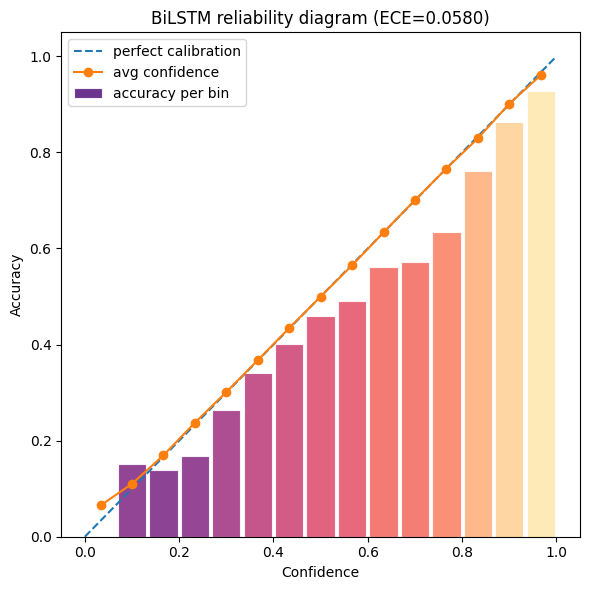

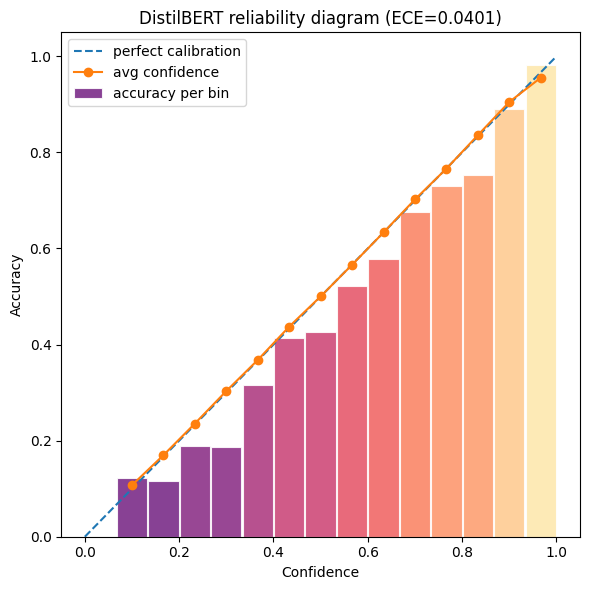

,dataset_variant,model,accuracy,f1_macro
0,clean,BiLSTM + GloVe,0.4853,0.4488
1,clean,DistilBERT,0.7146,0.6891
2,noise_0.05,BiLSTM + GloVe,0.4819,0.4461
3,noise_0.05,DistilBERT,0.7093,0.6835
4,noise_0.10,BiLSTM + GloVe,0.4744,0.4386
5,noise_0.10,DistilBERT,0.7043,0.6796


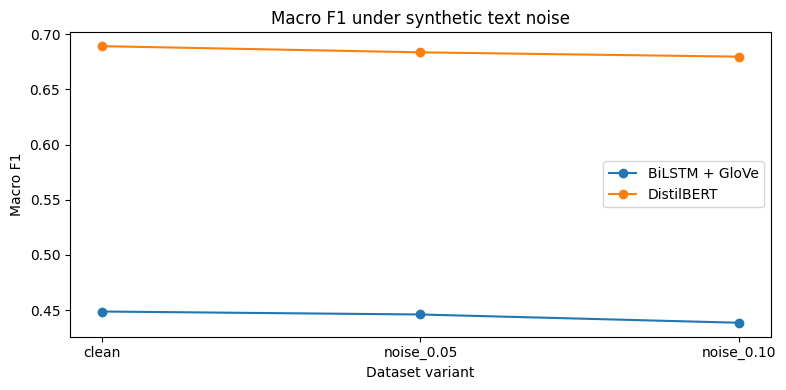

In [ ]:
# ==== Calibration + Robustness ====

# Calibration on clean test set
rnn_test_probs = logits_to_probs(rnn_test_logits)
tf_test_probs = logits_to_probs(tf_test_logits)

rnn_ece, rnn_calibration_df = compute_ece(rnn_test_labels_tensor.numpy(), rnn_test_probs, n_bins=15)
tf_ece, tf_calibration_df = compute_ece(tf_test_labels_tensor.numpy(), tf_test_probs, n_bins=15)

calibration_summary_df = pd.DataFrame([
    {"model": "BiLSTM + GloVe", "ECE": rnn_ece},
    {"model": "DistilBERT", "ECE": tf_ece},
]).sort_values(by="ECE")

display(calibration_summary_df.round(4))

plot_reliability_diagram(
    rnn_calibration_df,
    f"BiLSTM reliability diagram (ECE={rnn_ece:.4f})",
    cmap="magma"
)

plot_reliability_diagram(
    tf_calibration_df,
    f"DistilBERT reliability diagram (ECE={tf_ece:.4f})",
    cmap="magma"
)

# Robustness under synthetic noise / corruption
clean_eval_df = evaluate_models_on_df(test_df, severity_name="clean")
noise_005_df = make_noisy_df(test_df, severity=0.05, seed=SEED)
noise_010_df = make_noisy_df(test_df, severity=0.10, seed=SEED)

robustness_df = pd.concat([
    clean_eval_df,
    evaluate_models_on_df(noise_005_df, severity_name="noise_0.05"),
    evaluate_models_on_df(noise_010_df, severity_name="noise_0.10"),
], ignore_index=True)

display(robustness_df.round(4))

plt.figure(figsize=(8, 4))
for model_name in robustness_df["model"].unique():
    tmp = robustness_df[robustness_df["model"] == model_name]
    plt.plot(tmp["dataset_variant"], tmp["f1_macro"], marker="o", label=model_name)
plt.title("Macro F1 under synthetic text noise")
plt.xlabel("Dataset variant")
plt.ylabel("Macro F1")
plt.legend()
plt.tight_layout()
plt.show()


- **Train:** 9,912 mẫu
- **Validation:** 1,102 mẫu
- **Test:** 7,317 mẫu
- **Số lớp:** 20


In [ ]:
# ===== Slide-friendly summary tables =====

slide_summary_df = enhanced_comparison_df.copy()

cols_to_keep = [
    "model", "group", "test_accuracy", "test_f1_macro",
    "val_f1_macro_best", "training_time_minutes", "trainable_params"
]
slide_summary_df = slide_summary_df[cols_to_keep].copy()

slide_summary_df["test_accuracy"] = slide_summary_df["test_accuracy"].round(4)
slide_summary_df["test_f1_macro"] = slide_summary_df["test_f1_macro"].round(4)
slide_summary_df["val_f1_macro_best"] = slide_summary_df["val_f1_macro_best"].round(4)
slide_summary_df["training_time_minutes"] = slide_summary_df["training_time_minutes"].round(2)
slide_summary_df["trainable_params_m"] = (slide_summary_df["trainable_params"] / 1_000_000).round(2)
slide_summary_df = slide_summary_df.drop(columns=["trainable_params"])

print("=== Final model summary for slides ===")
display(slide_summary_df)

print("=== Top confusion pairs: BiLSTM ===")
display(top_confusions_from_cm(rnn_cm, label_names, top_k=10))

print("=== Top confusion pairs: DistilBERT ===")
display(top_confusions_from_cm(tf_cm, label_names, top_k=10))

robustness_pivot = robustness_df.pivot(
    index="dataset_variant", columns="model", values="f1_macro"
).round(4)

print("=== Robustness summary (Macro F1) ===")
display(robustness_pivot)

slide_summary_df.to_csv(RESULTS_DIR / "slide_final_summary.csv", index=False)
robustness_pivot.to_csv(RESULTS_DIR / "slide_robustness_pivot.csv")

=== Final model summary for slides ===


,model,group,test_accuracy,test_f1_macro,val_f1_macro_best,training_time_minutes,trainable_params_m
0,DistilBERT,Transformer,0.7146,0.6891,0.7152,13.15,66.97
1,Weighted Ensemble (alpha_tf=1.00),Ensemble,0.7146,0.6891,0.7152,14.68,69.21
2,BiLSTM + GloVe,RNN,0.4853,0.4488,0.4642,1.54,2.24


=== Top confusion pairs: BiLSTM ===


,true_label,predicted_label,count
0,rec.sport.hockey,rec.sport.baseball,324
1,comp.graphics,comp.windows.x,170
2,talk.politics.guns,talk.politics.misc,145
3,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,115
4,rec.motorcycles,rec.autos,98
5,alt.atheism,soc.religion.christian,81
6,talk.religion.misc,soc.religion.christian,75
7,sci.electronics,sci.space,66
8,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,65
9,rec.autos,rec.motorcycles,65


=== Top confusion pairs: DistilBERT ===


,true_label,predicted_label,count
0,talk.religion.misc,soc.religion.christian,106
1,talk.politics.misc,talk.politics.guns,88
2,alt.atheism,soc.religion.christian,73
3,talk.religion.misc,alt.atheism,70
4,comp.sys.mac.hardware,comp.sys.ibm.pc.hardware,53
5,rec.motorcycles,rec.autos,46
6,comp.windows.x,comp.os.ms-windows.misc,41
7,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,40
8,soc.religion.christian,alt.atheism,38
9,sci.electronics,comp.sys.ibm.pc.hardware,33


=== Robustness summary (Macro F1) ===


model,BiLSTM + GloVe,DistilBERT
dataset_variant,,
clean,0.4488,0.6891
noise_0.05,0.4461,0.6835
noise_0.10,0.4386,0.6796


### Note viết báo cáo

1. **Efficiency**: DistilBERT mạnh hơn về F1 nhưng chậm hơn đáng kể; BiLSTM nhẹ và nhanh hơn.
2. **Ensemble**: nếu ensemble vượt mô hình tốt nhất, giải thích là hai mô hình mắc lỗi khác nhau nên kết hợp giúp bù trừ.
3. **Calibration**: mô hình nào có ECE thấp hơn thì đáng tin hơn về mặt xác suất dự đoán.
4. **Robustness**: mô hình nào bị giảm F1 ít hơn khi thêm nhiễu thì bền vững hơn với dữ liệu thực tế.